## Создание фич

In [1]:
import polars as pl 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path


In [2]:
data_dir = Path("../data/")


In [3]:
df = pl.read_parquet(data_dir / "g5_2xlarge_6h_after_2024-07.parquet")
df

datetime,cost
datetime[μs],f16
2024-07-01 00:00:00,0.911621
2024-07-01 06:00:00,0.913574
2024-07-01 12:00:00,0.9140625
2024-07-01 18:00:00,0.912109
2024-07-02 00:00:00,0.911621
…,…
2026-02-27 18:00:00,1.011719
2026-02-28 00:00:00,1.011719
2026-02-28 06:00:00,1.013672


## Перейдем к генерации лагов

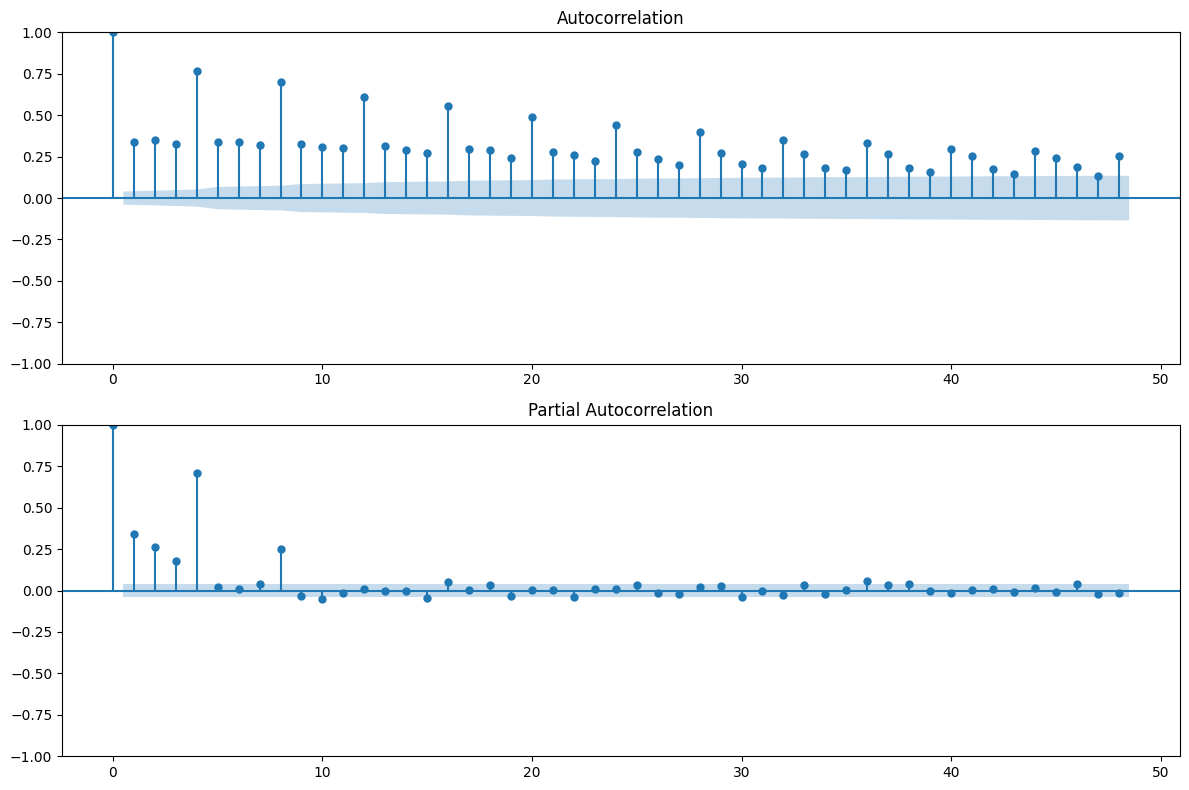

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df["cost"].to_numpy(), lags=48, ax=axes[0])
plot_pacf(df["cost"].to_numpy(), lags=48, ax=axes[1])
plt.tight_layout()

возьмем лаги 1 2 3 4(сутки) 8(2 суток) и 28(неделя)

In [5]:
df = df.with_columns(
    pl.col("cost").shift(1).alias("cost_lag_6h"),
    pl.col("cost").shift(2).alias("cost_lag_12h"),
    pl.col("cost").shift(3).alias("cost_lag_18h"),
    pl.col("cost").shift(4).alias("cost_lag_1d"),
    pl.col("cost").shift(8).alias("cost_lag_2d"),
    pl.col("cost").shift(28).alias("cost_lag_1w")
    )

df

datetime,cost,cost_lag_6h,cost_lag_12h,cost_lag_18h,cost_lag_1d,cost_lag_2d,cost_lag_1w
datetime[μs],f16,f16,f16,f16,f16,f16,f16
2024-07-01 00:00:00,0.911621,null,null,null,null,null,null
2024-07-01 06:00:00,0.913574,0.911621,null,null,null,null,null
2024-07-01 12:00:00,0.9140625,0.913574,0.911621,null,null,null,null
2024-07-01 18:00:00,0.912109,0.9140625,0.913574,0.911621,null,null,null
2024-07-02 00:00:00,0.911621,0.912109,0.9140625,0.913574,0.911621,null,null
…,…,…,…,…,…,…,…
2026-02-27 18:00:00,1.011719,1.012695,1.012695,0.956055,1.008789,1.003906,1.005859
2026-02-28 00:00:00,1.011719,1.011719,1.012695,1.012695,0.956055,0.94873,1.02832
2026-02-28 06:00:00,1.013672,1.011719,1.011719,1.012695,1.012695,1.003906,1.033203


## Теперь фичи

к лагам прибавим праздники

In [6]:
import holidays

us_holidays = holidays.US(years=range(2022, 2027))

df = df.with_columns([
    pl.col("datetime").dt.hour().alias("hour"),
    pl.col("datetime").dt.weekday().alias("weekday"),       # 0=пн, 6=вс
    pl.col("datetime").dt.month().alias("month"),
    pl.col("datetime").dt.day().alias("day"),
    pl.col("datetime").dt.week().alias("week_of_year"),
    (pl.col("datetime").dt.weekday() >= 5).cast(pl.Int8).alias("is_weekend"),
    pl.col("datetime").map_elements(
        lambda x: int(x.date() in us_holidays),
        return_dtype=pl.Int8
    ).alias("is_holiday"),
])
df 

datetime,cost,cost_lag_6h,cost_lag_12h,cost_lag_18h,cost_lag_1d,cost_lag_2d,cost_lag_1w,hour,weekday,month,day,week_of_year,is_weekend,is_holiday
datetime[μs],f16,f16,f16,f16,f16,f16,f16,i8,i8,i8,i8,i8,i8,i8
2024-07-01 00:00:00,0.911621,null,null,null,null,null,null,0,1,7,1,27,0,0
2024-07-01 06:00:00,0.913574,0.911621,null,null,null,null,null,6,1,7,1,27,0,0
2024-07-01 12:00:00,0.9140625,0.913574,0.911621,null,null,null,null,12,1,7,1,27,0,0
2024-07-01 18:00:00,0.912109,0.9140625,0.913574,0.911621,null,null,null,18,1,7,1,27,0,0
2024-07-02 00:00:00,0.911621,0.912109,0.9140625,0.913574,0.911621,null,null,0,2,7,2,27,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-02-27 18:00:00,1.011719,1.012695,1.012695,0.956055,1.008789,1.003906,1.005859,18,5,2,27,9,1,0
2026-02-28 00:00:00,1.011719,1.011719,1.012695,1.012695,0.956055,0.94873,1.02832,0,6,2,28,9,1,0
2026-02-28 06:00:00,1.013672,1.011719,1.011719,1.012695,1.012695,1.003906,1.033203,6,6,2,28,9,1,0


часы и дни недели цикличны, добавим это:

In [7]:
import numpy as np


df = df.with_columns([
    (2 * np.pi * pl.col("hour") / 24).sin().alias("hour_sin"),
    (2 * np.pi * pl.col("hour") / 24).cos().alias("hour_cos"),
    (2 * np.pi * pl.col("weekday") / 7).sin().alias("weekday_sin"),
    (2 * np.pi * pl.col("weekday") / 7).cos().alias("weekday_cos"),
])

добавим производных

In [8]:
df = df.with_columns([
    # скорость изменения цены
    (pl.col("cost") - pl.col("cost").shift(1)).alias("cost_diff"),
    # процентное изменение
    ((pl.col("cost") - pl.col("cost").shift(1)) / pl.col("cost").shift(1)).alias("cost_pct_change"),
    # насколько текущая цена выше/ниже скользящего среднего
    (pl.col("cost") / pl.col("cost").rolling_mean(28)).alias("cost_vs_mean"),
])

соотношение с on_demand 

In [9]:
ON_DEMAND = 1.212
df = df.with_columns(
    (pl.col("cost") / ON_DEMAND).alias("discount_ratio")
)


Добавим таргет

In [10]:
df = df.with_columns(
    pl.col("cost").shift(-4).alias("target_сost")  # 4 слота × 6h = 24h вперёд
)

In [11]:
df = df.drop_nulls().with_columns(
    pl.col(pl.Float16).cast(pl.Float32)
)

In [12]:
df

datetime,cost,cost_lag_6h,cost_lag_12h,cost_lag_18h,cost_lag_1d,cost_lag_2d,cost_lag_1w,hour,weekday,month,day,week_of_year,is_weekend,is_holiday,hour_sin,hour_cos,weekday_sin,weekday_cos,cost_diff,cost_pct_change,cost_vs_mean,discount_ratio,target_сost
datetime[μs],f32,f32,f32,f32,f32,f32,f32,i8,i8,i8,i8,i8,i8,i8,f64,f64,f64,f64,f32,f32,f64,f32,f32
2024-07-08 00:00:00,0.912109,0.90918,0.907715,0.905762,0.903809,0.84668,0.911621,0,1,7,8,28,0,0,0.0,1.0,0.781831,0.62349,0.00293,0.003222,1.013388,0.752441,0.916992
2024-07-08 06:00:00,0.856934,0.912109,0.90918,0.907715,0.905762,0.90625,0.913574,6,1,7,8,28,0,0,1.0,6.1232e-17,0.781831,0.62349,-0.055176,-0.060486,0.95423,0.707031,0.918945
2024-07-08 12:00:00,0.9140625,0.856934,0.912109,0.90918,0.907715,0.905273,0.9140625,12,1,7,8,28,0,0,1.2246e-16,-1.0,0.781831,0.62349,0.057129,0.06665,1.017846,0.754395,0.920898
2024-07-08 18:00:00,0.916504,0.9140625,0.856934,0.912109,0.90918,0.848633,0.912109,18,1,7,8,28,0,0,-1.0,-1.8370e-16,0.781831,0.62349,0.002441,0.00267,1.020386,0.756348,0.921875
2024-07-09 00:00:00,0.916992,0.916504,0.9140625,0.856934,0.912109,0.903809,0.911621,0,2,7,9,28,0,0,0.0,1.0,0.974928,-0.222521,0.000488,0.000533,1.020712,0.756836,0.922852
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-02-26 18:00:00,1.008789,1.004883,1.003906,0.94873,1.003906,1.000977,1.043945,18,4,2,26,9,0,0,-1.0,-1.8370e-16,-0.433884,-0.900969,0.003906,0.003887,1.002913,0.83252,1.011719
2026-02-27 00:00:00,0.956055,1.008789,1.004883,1.003906,0.94873,1.0,1.035156,0,5,2,27,9,1,0,0.0,1.0,-0.974928,-0.222521,-0.052734,-0.052277,0.953162,0.7890625,1.011719
2026-02-27 06:00:00,1.012695,0.956055,1.008789,1.004883,1.003906,1.000977,1.014648,6,5,2,27,9,1,0,1.0,6.1232e-17,-0.974928,-0.222521,0.056641,0.059235,1.009702,0.835449,1.013672


Сохраним фичи

In [13]:
df.write_parquet(data_dir / "g5_2xlarge_6h_after_2024-07_with_features.parquet")

## Baseline

In [17]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

feature_cols = [c for c in df.columns if c not in ["datetime", "target_сost"]]

X = df[feature_cols].to_numpy()
y = df["target_сost"].to_numpy()

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # baseline: предсказываем cost_lag_1w
    lag_1_idx = feature_cols.index("cost_lag_1w")
    y_pred = X_test[:, lag_1_idx]
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    print(f"Fold {fold+1}: MAE={mae:.4f}, RMSE={rmse:.4f}, MAPE={mape:.2f}%")

Fold 1: MAE=0.2546, RMSE=0.4052, MAPE=26.08%
Fold 2: MAE=0.2236, RMSE=0.3398, MAPE=20.86%
Fold 3: MAE=0.2532, RMSE=0.3525, MAPE=25.33%
Fold 4: MAE=0.2359, RMSE=0.3270, MAPE=22.91%
Fold 5: MAE=0.2149, RMSE=0.2711, MAPE=16.88%


#### Итог BASELINE:

#### MAE=0.2034, RMSE=0.2617, MAPE=15.96%